Denna notebook används för undersökning av lämpligt val av paramtern r i avklustringen.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import EVTLibrary as evt
importlib.reload(evt)
from scipy import stats
from scipy.stats import genpareto
from scipy.stats import kstest
import matplotlib.patches as mpatches

In [2]:
u_prel = [0.041, 0.035, 0.042, 0.035, 0.045, 0.044, 0.046, 0.045, 0.040, 0.037]
loss_df = evt.get_data(start="2000-01-01", end="2026-03-31")
u, extreme_values = evt.get_extreme_data(u_prel, loss_df, False)

### Illustration över avklustringsmetoden (under finanskrisen 2008)

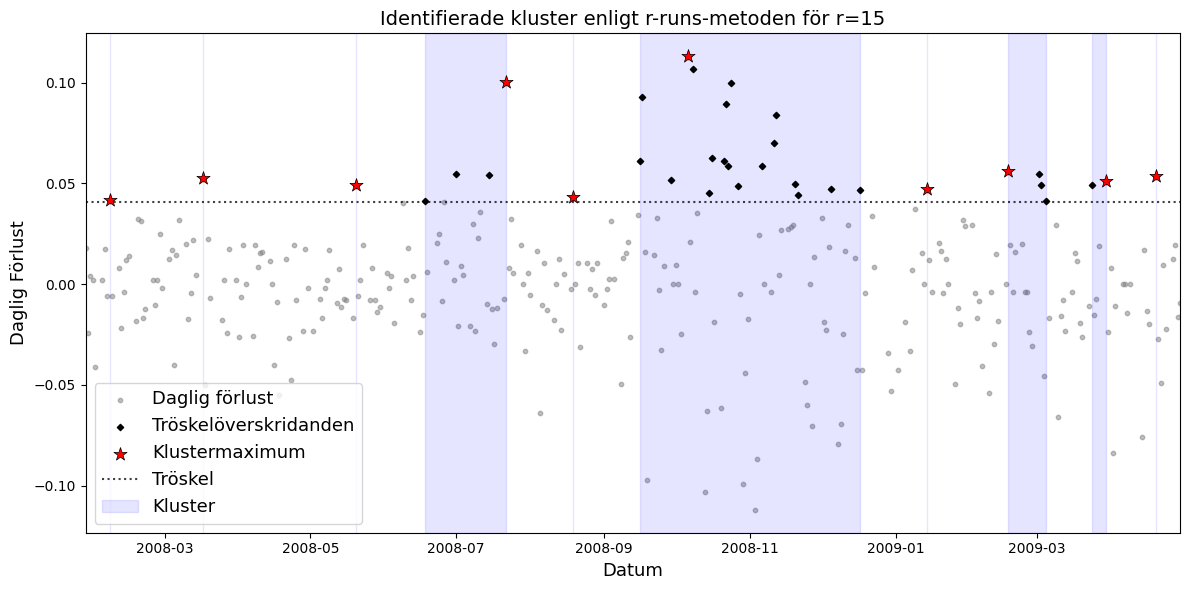

2008-01-28 00:00:00
2009-04-30 00:00:00


In [3]:
cluster_maxima, clustered_exceedances = evt.get_cluster_maxima(u, extreme_values, r=15)

ce = clustered_exceedances["Kinnevik B"]
cm = cluster_maxima["Kinnevik B"]

clusters = cm["Cluster"].unique()[20:30]
subset_exceedances = ce[ce["Cluster"].isin(clusters)]
subset_maxima = cm[cm["Cluster"].isin(clusters)]

start = subset_exceedances.index.min() - pd.Timedelta(days=10)
end = subset_exceedances.index.max() + pd.Timedelta(days=10)

loss_window = loss_df["Kinnevik B"].loc[start:end]
max_window = cm.loc[start:end]

plt.figure(figsize=(12, 6))

# Alla observationer i fönstret
plt.scatter(loss_window.index, loss_window.values, color="grey", alpha=0.5, s=10, label="Daglig förlust")

# Alla exceedances i de valda klustren
plt.scatter(subset_exceedances.index, subset_exceedances["Loss"], marker = "D", color="black", s=10, zorder=3, label="Tröskelöverskridanden")

# Klustermaxima
plt.scatter(subset_maxima.index, subset_maxima["Loss"], marker="*", s=100, color="red", edgecolor="black", linewidth=0.5, zorder=4, label="Klustermaximum")

# Tröskel
plt.axhline(u["Kinnevik B"],color="black", alpha = 0.75, linestyle=":", label="Tröskel")

# Skuggade kluster
for i, (_, group) in enumerate(subset_exceedances.groupby("Cluster")):
    label = "Kluster" if i == 0 else None
    plt.axvspan(group.index.min(), group.index.max(), alpha=0.1, color="blue", label=label)

plt.xlim(start, end)
plt.title("Identifierade kluster enligt r-runs-metoden för r=15", fontsize=14)
plt.xlabel("Datum", fontsize=13)
plt.ylabel("Daglig Förlust", fontsize=13)
plt.grid(False)
plt.legend(fontsize = 13, loc = "lower left")
plt.tight_layout()
plt.show()
print(start)
print(end)

### Här skapas en tabell av skattade parametrar för olika r-värden 

In [4]:
r_list = [5, 10, 15, 20]
m = 100*252
rows = []

for r in r_list:
    r = int(r)
    cluster_maxima, _ = evt.get_cluster_maxima(u, extreme_values, r)

    for stock in loss_df.columns:
        cm = cluster_maxima[stock]["Loss"].dropna().to_numpy()

        xi_hat, _, sigma_hat = stats.genpareto.fit(cm - u[stock], floc=0)

        n_clusters = len(cluster_maxima[stock]["Loss"].dropna())
        n_exceedances = len(extreme_values[stock].dropna())

        # Extremal index
        theta_hat = n_clusters / n_exceedances

        # Totala antalet observationer
        n_total = len(loss_df[stock].dropna())

        # zeta_u = empirisk sannolikhet för överskridande
        rate = n_exceedances / n_total

        # Kovariansmatrisen för [sigma_hat, xi_hat]
        cov_mat = evt.gpd_cov_matrix(excesses=cm, sigma_hat=sigma_hat, xi_hat=xi_hat)

        # Standardfel för sigma och xi
        sigma_se = np.sqrt(cov_mat[0, 0])
        xi_se = np.sqrt(cov_mat[1, 1])

        # Return-level
        xm = evt.return_level_hat(u=u[stock], sigma_hat=sigma_hat, xi_hat=xi_hat, rate=rate, m=m)

        # Standardfel för return-level
        xm_se = evt.return_level_se(u=u[stock], sigma_hat=sigma_hat, xi_hat=xi_hat, rate=rate, n_total=n_total, cov_mat=cov_mat,m=m)
   
        # Extrahera alla skattningar för varje r och aktie 
        rows.append({"stock": stock, 
                    "r": r, 
                    "n_total": n_total,
                    "n_exceedances": n_exceedances,
                    "n_clusters": n_clusters,
                    "zeta_u_hat": rate,
                    "theta_hat": theta_hat,
                    "xi_hat": xi_hat,
                    "xi_se": xi_se,
                    "sigma_hat": sigma_hat,
                    "sigma_se": sigma_se,
                    "xm_hat": xm,
                    "xm_se": xm_se
                    })

cluster_results_df = pd.DataFrame(rows)

In [5]:
# Funkioner som definieras för att kunna skapa specifika tabeller för visualisering av all data ovan

def est_se(est, se, digits=4):
    return f"{est:.{digits}f} ({se:.{digits}f})"


def make_stock_table(df, stock, digits=4):
    sub = df[df["stock"] == stock].copy()
    sub = sub.sort_values("r")

    index = ["n_c","sigma_hat","xi_hat","xm_hat", "theta_hat"]

    table = pd.DataFrame(index=index, dtype=object)

    for _, row in sub.iterrows():
        r_val = int(row["r"])
        r_col = f"r={r_val}"

        values = {
            "n_c": f"{int(row['n_clusters'])}",
            "sigma_hat": est_se(row["sigma_hat"], row["sigma_se"], digits),
            "xi_hat": est_se(row["xi_hat"], row["xi_se"], digits),
            "xm_hat": est_se(row["xm_hat"], row["xm_se"], digits),
            "theta_hat": f"{row['theta_hat']:.2f}",
        }

        for param, value in values.items():
            table.loc[param, r_col] = value

    table = table.reset_index()
    table = table.rename(columns={"index": ""})

    return table

In [6]:
for stock in loss_df.columns:
    print(stock)
    display(make_stock_table(cluster_results_df, stock))
    print("-----------------------------------")

Kinnevik B


,,r=5,r=10,r=15,r=20
0,n_c,140,113,89,81
1,sigma_hat,0.0194 (0.0016),0.0211 (0.0020),0.0242 (0.0025),0.0260 (0.0028)
2,xi_hat,0.2361 (0.0647),0.2485 (0.0776),0.2206 (0.0889),0.1990 (0.0922)
3,xm_hat,0.3568 (0.0681),0.4022 (0.0956),0.4108 (0.1100),0.4036 (0.1096)
4,theta_hat,0.72,0.58,0.46,0.42


-----------------------------------
Investor B


,,r=5,r=10,r=15,r=20
0,n_c,89,68,57,53
1,sigma_hat,0.0124 (0.0011),0.0116 (0.0013),0.0111 (0.0014),0.0116 (0.0015)
2,xi_hat,0.1152 (0.0503),0.1901 (0.0669),0.2577 (0.0822),0.2508 (0.0869)
3,xm_hat,0.1481 (0.0136),0.1744 (0.0250),0.2071 (0.0415),0.2106 (0.0446)
4,theta_hat,0.71,0.54,0.45,0.42


-----------------------------------
SEB A


...

-----------------------------------
Boliden


,,r=5,r=10,r=15,r=20
0,n_c,223,159,131,114
1,sigma_hat,0.0221 (0.0014),0.0196 (0.0016),0.0187 (0.0017),0.0207 (0.0020)
2,xi_hat,0.1747 (0.0496),0.2694 (0.0664),0.3184 (0.0776),0.2918 (0.0837)
3,xm_hat,0.3550 (0.0536),0.4661 (0.1082),0.5528 (0.1600),0.5401 (0.1650)
4,theta_hat,0.72,0.51,0.42,0.37


-----------------------------------
SCA B


,,r=5,r=10,r=15,r=20
0,n_c,81,68,60,55
1,sigma_hat,0.0111 (0.0011),0.0121 (0.0013),0.0116 (0.0014),0.0132 (0.0016)
2,xi_hat,0.2039 (0.0588),0.2010 (0.0680),0.2566 (0.0800),0.2055 (0.0817)
3,xm_hat,0.1678 (0.0197),0.1778 (0.0246),0.2035 (0.0369),0.1930 (0.0334)
4,theta_hat,0.82,0.69,0.61,0.56


-----------------------------------


### Illustrationer av return-level-plots för olika r-värden

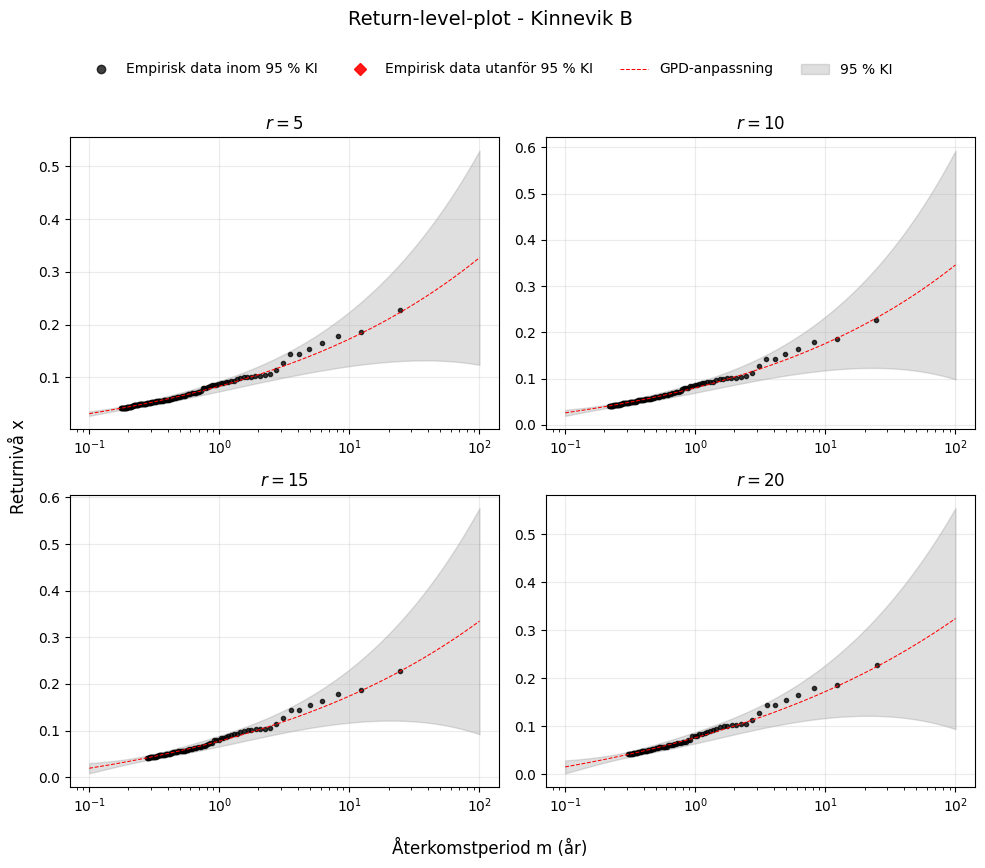

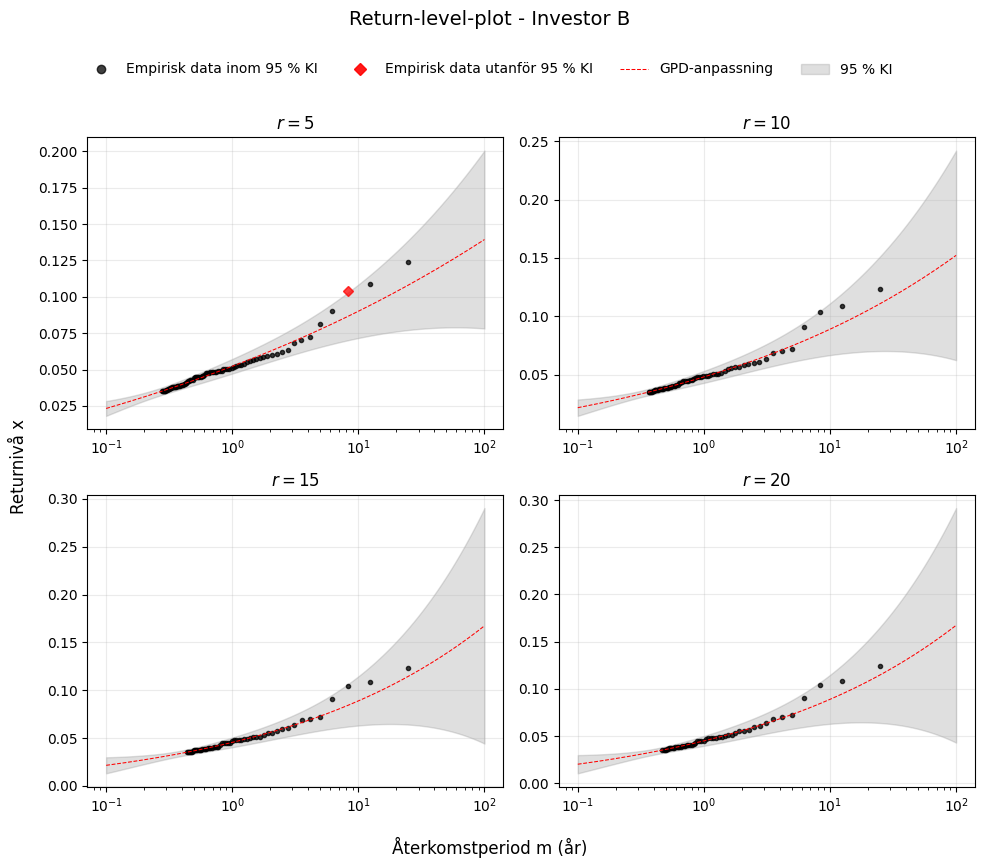

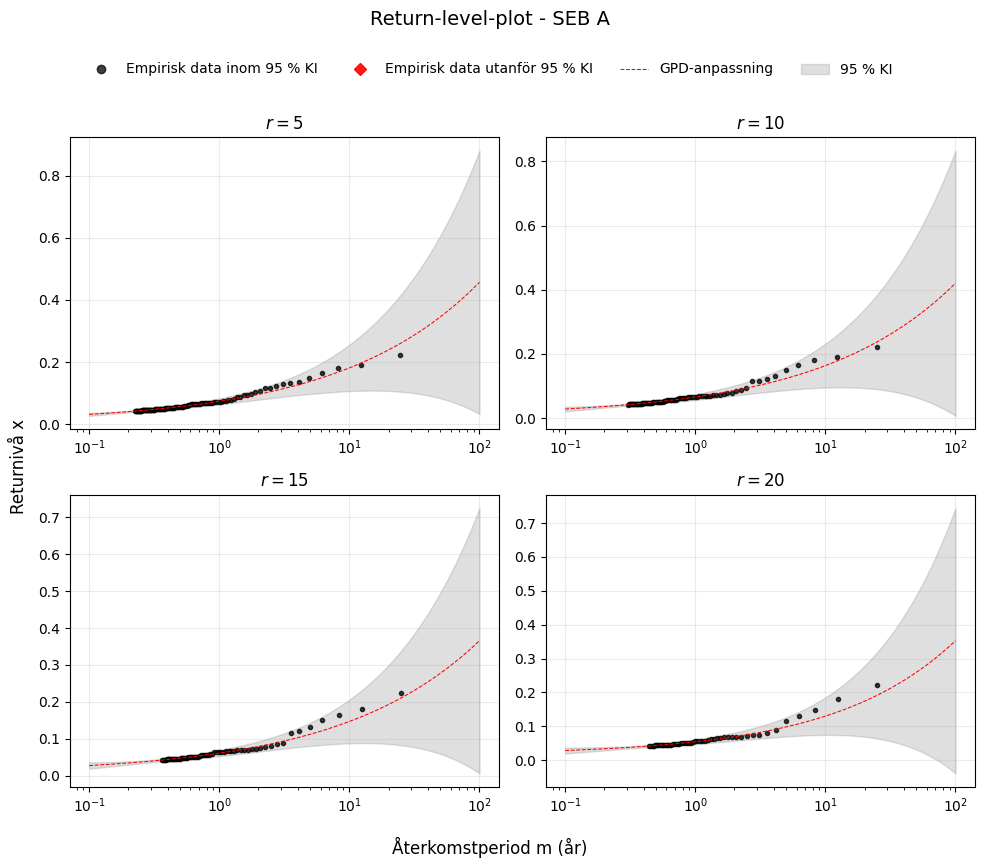

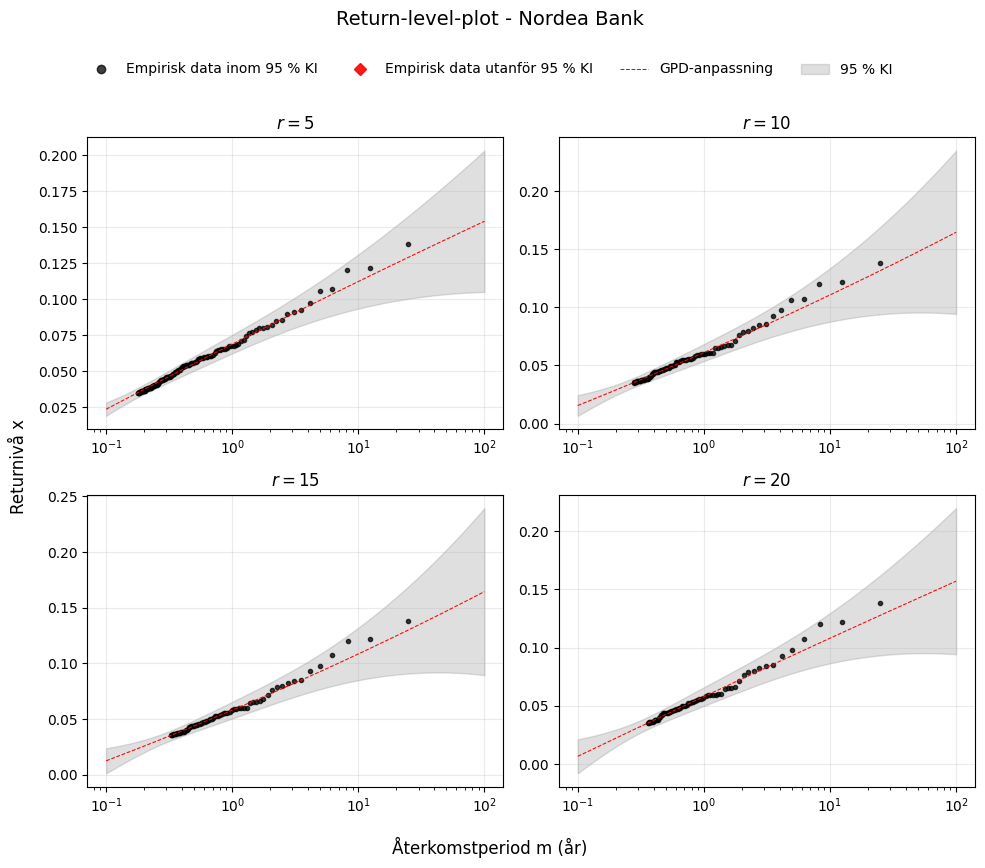

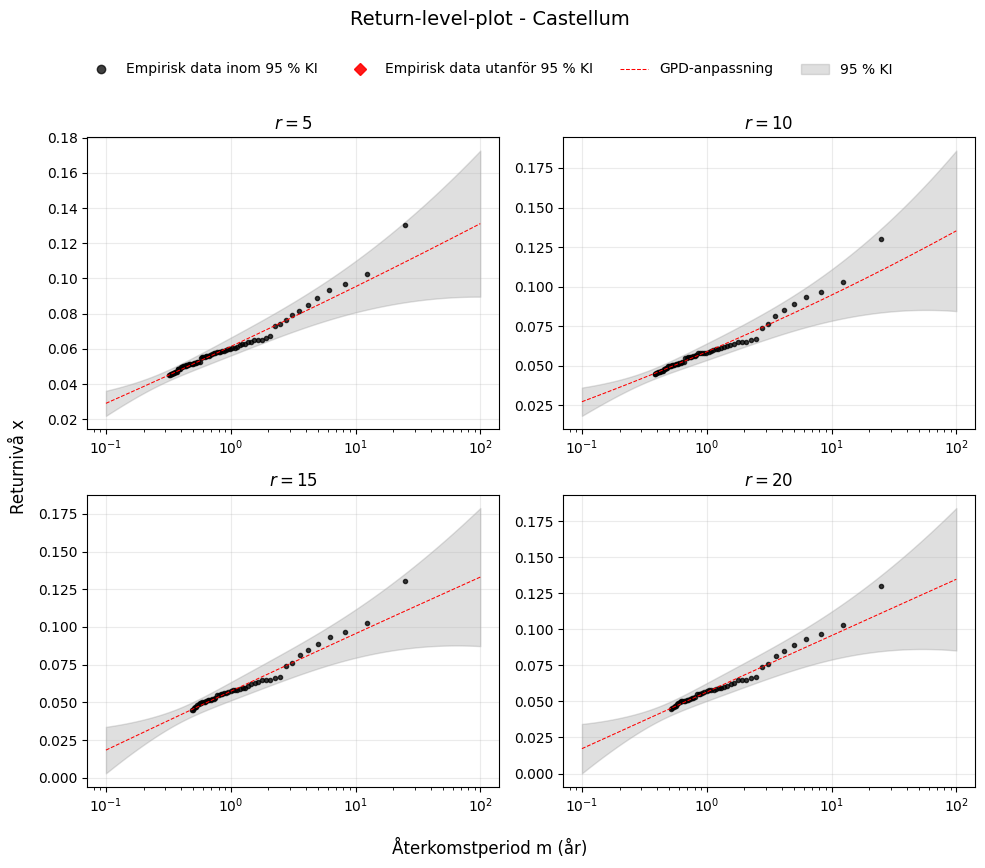

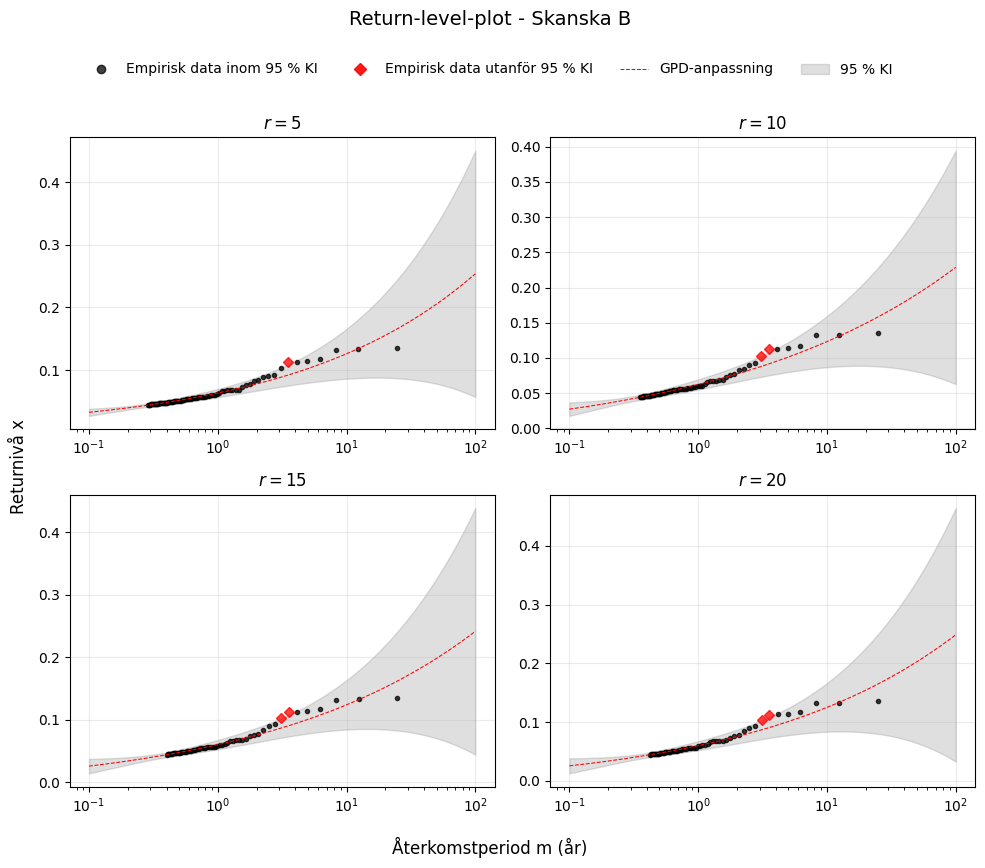

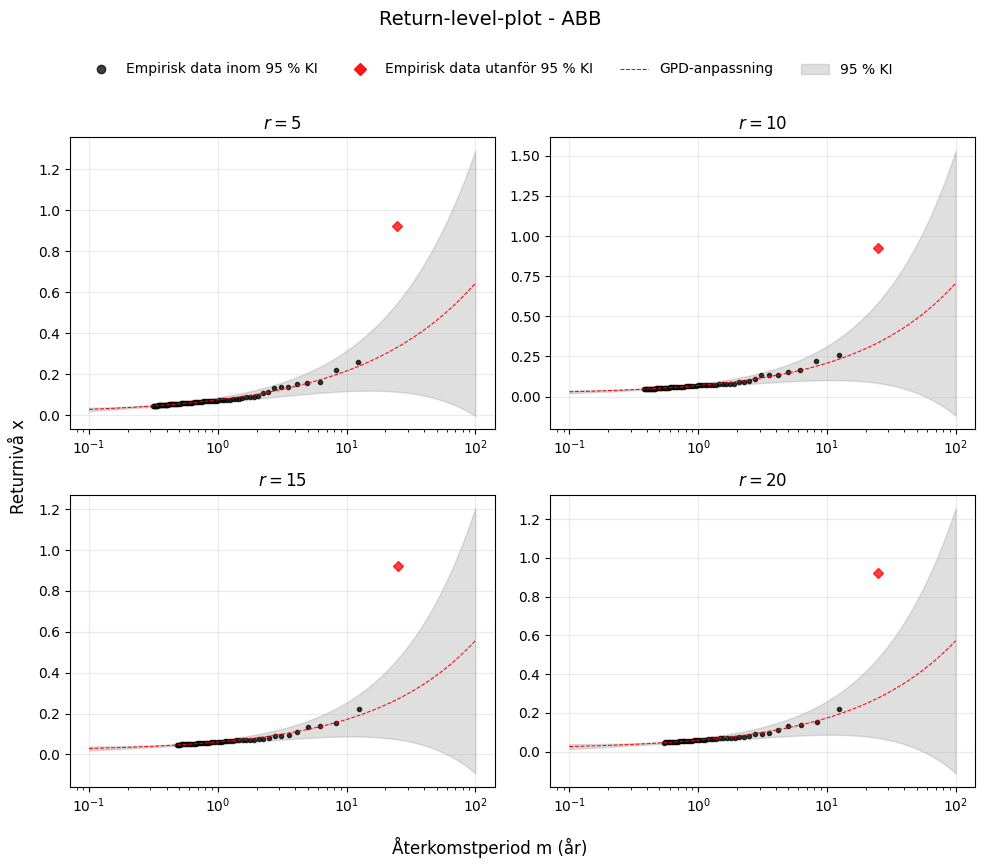

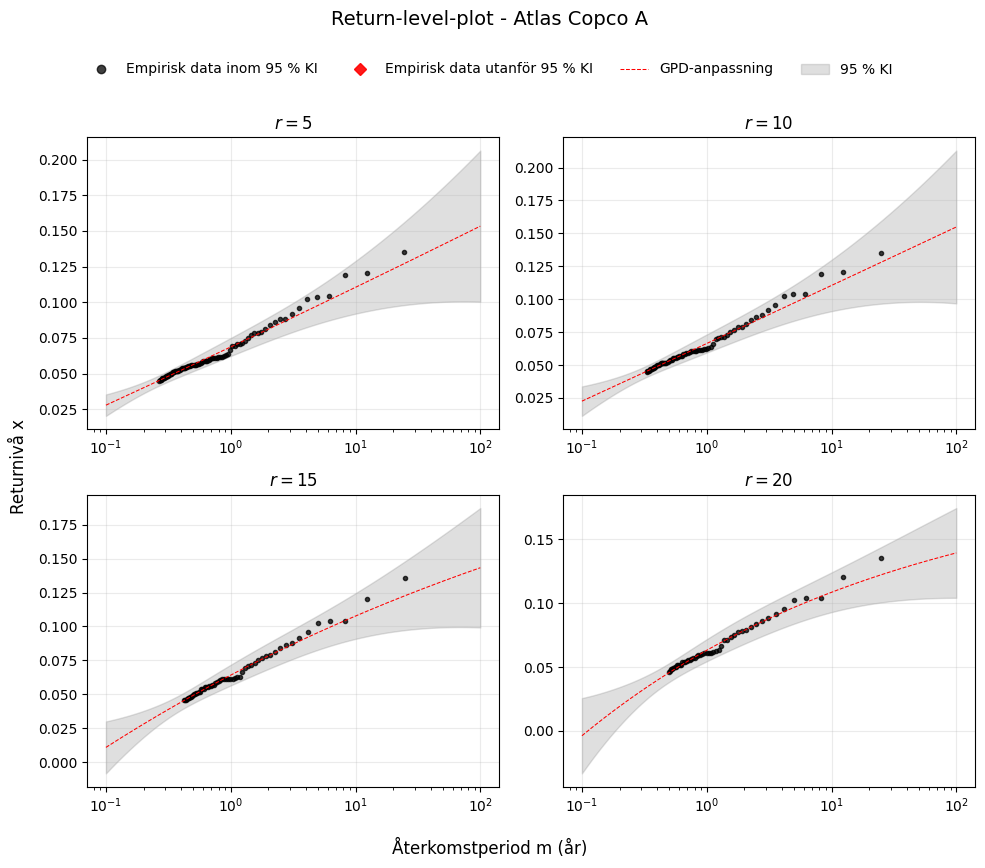

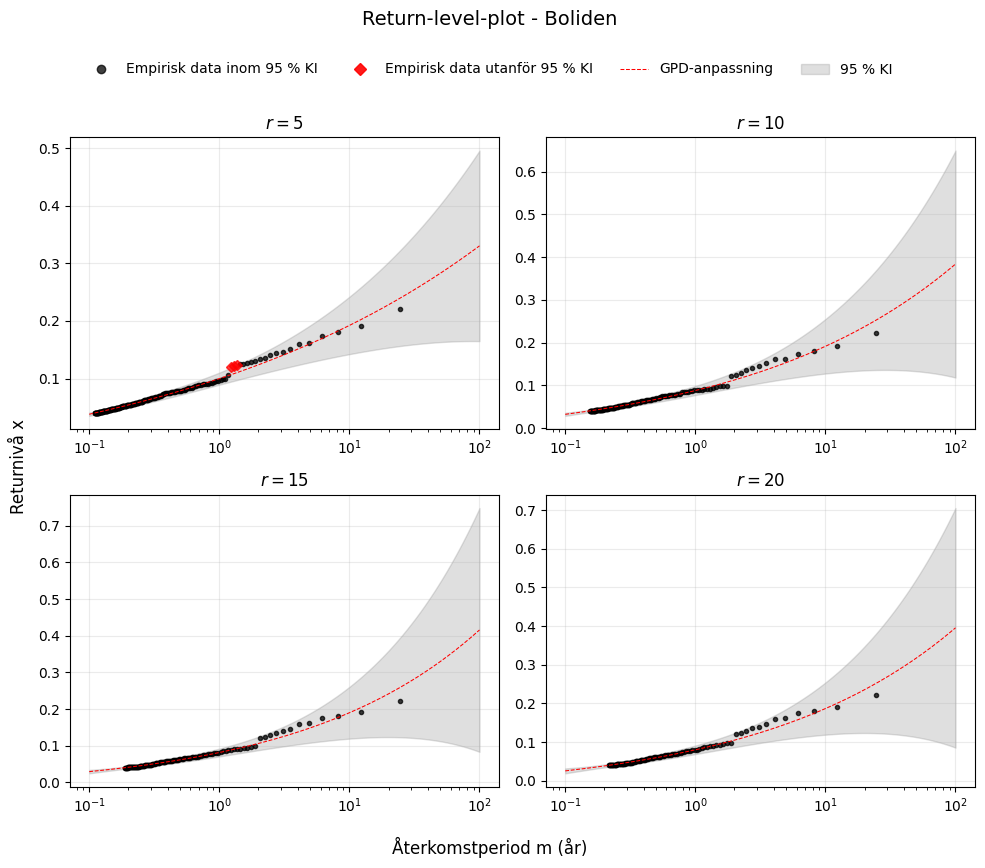

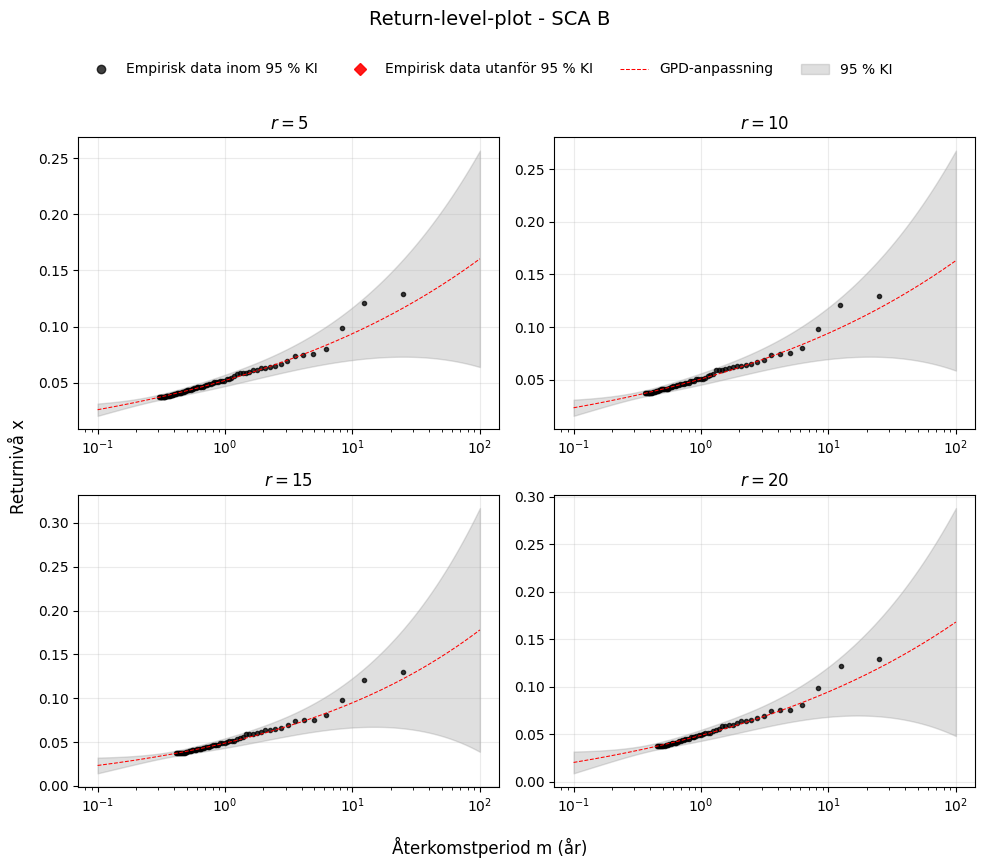

In [7]:
r_list = [5, 10, 15, 20]

m_max_years = 100
m_grid = np.logspace(np.log10(0.1 * 252), np.log10(m_max_years * 252), 200)

for stock in loss_df.columns:

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.ravel()

    for i, r in enumerate(r_list):

        ax = axes[i]

        # Klustermaxima för valt r
        cluster_maxima, _ = evt.get_cluster_maxima(u, extreme_values, int(r))

        cm = cluster_maxima[stock]["Loss"].dropna().to_numpy()
        y_arr = cm - u[stock]

        k_clusters = len(y_arr)
        n_exceedances = len(extreme_values[stock].dropna())
        n_total = len(loss_df[stock].dropna())

        # Skatta GPD-parametrar på klusterexcesser
        xi_hat, _, sigma_hat = stats.genpareto.fit(y_arr, floc=0)

        # Empirisk exceedance rate över tröskeln
        rate = n_exceedances / n_total

        # Sorterade observerade klustermaxima
        y_sorted = np.sort(y_arr)
        x_sorted = u[stock] + y_sorted

        # Empiriska återkomstperioder
        ranks = np.arange(1, k_clusters + 1)
        p_tail = (k_clusters + 1 - ranks) / (k_clusters + 1)

        # Här används extremalindex genom klustringen:
        # antal kluster per observation approx theta * zeta_u
        theta_hat = k_clusters / n_exceedances
        cluster_rate = theta_hat * rate

        m_emp = 1 / (p_tail * cluster_rate)

        # Kovariansmatris för [sigma_hat, xi_hat]
        cov_mat = evt.gpd_cov_matrix(excesses=y_arr, sigma_hat=sigma_hat, xi_hat=xi_hat)

        # Teoretisk return level-kurva
        x_th = np.array([evt.return_level_hat(u=u[stock], sigma_hat=sigma_hat, xi_hat=xi_hat, rate=cluster_rate, m=m) for m in m_grid])

        # Standardfel för return levels
        se = np.array([evt.return_level_se(u=u[stock], sigma_hat=sigma_hat, xi_hat=xi_hat, rate=cluster_rate, n_total=n_total, cov_mat=cov_mat, m=m) for m in m_grid])

        # Interpolera teoretisk returnivå och KI till empiriska m-värden
        x_interp = np.interp(m_emp, m_grid, x_th)
        se_interp = np.interp(m_emp, m_grid, se)

        lower = x_interp - 1.96 * se_interp
        upper = x_interp + 1.96 * se_interp

        # Markera empiriska punkter som ligger utanför 95 % KI
        outside = (x_sorted < lower) | (x_sorted > upper)
        inside = ~outside

        # Empiriska punkter inom KI
        ax.semilogx(m_emp[inside] / 252, x_sorted[inside], marker="o", linestyle="None", markersize=3, color="black", alpha=0.75)

        # Empiriska punkter utanför KI
        ax.semilogx(m_emp[outside] / 252, x_sorted[outside], marker="D", linestyle="None", markersize=5, color="red", alpha=0.75)

        # GPD-anpassning
        ax.semilogx(m_grid / 252, x_th,"--",color="red", linewidth=0.75)

        # 95 % konfidensintervall
        ax.fill_between(m_grid / 252, x_th - 1.96 * se, x_th + 1.96 * se, color="gray", alpha=0.25)

        ax.set_title(f"$r={r}$", fontsize=12)
        ax.grid(True, alpha=0.25)

    handles = [
        plt.Line2D( [], [], marker="o",linestyle="None",color="black",alpha=0.75,label="Empirisk data inom 95 % KI"),
        plt.Line2D([], [],marker="D",linestyle="None",color="red",alpha=0.9,label="Empirisk data utanför 95 % KI"),
        plt.Line2D([], [],color="red",linestyle="--",linewidth=0.75,label="GPD-anpassning"),
        mpatches.Patch(color="gray",alpha=0.25,label="95 % KI")
    ]

    fig.legend(handles=handles,loc="upper center",bbox_to_anchor=(0.5, 1.02),ncol=4,frameon=False)

    fig.suptitle(f"Return-level-plot - {stock}", y=1.07, fontsize=14)
    fig.supxlabel("Återkomstperiod m (år)", fontsize=12)
    fig.supylabel("Returnivå x", fontsize=12)

    plt.tight_layout()
    plt.show()